# FX Volatility Forecasting Notebook

This notebook demonstrates a workflow for predicting future FX volatility using candle data. It covers feature engineering, model training, and evaluation.

## Contents

1. [Modules](#Modules) – Import necessary Python packages and custom modules.  
2. [Data](#Data) – Load and inspect FX candle data, including timestamps, open, high, low, and close prices.  
3. [Features](#Features) - Compute features such as log returns and high-low ranges.
- [High-low range](#high-low-range)
- [Open-close difference](#open-close-difference)
- [Log returns](#log-returns)
- [Logged lag returns](#logged-lag-returns)
- [Rolling statistics of log returns](#rolling-statistics-of-log-returnsfeature)
- [Past rolling volatility](#past-rolling-volatility)
- [Lagged rolling volatility](#lagged-rolling-volatility)
- [Multi-window rolling volatility](#multi-window-rolling-volatility)
- [Volatility slope](#volatility-slope)
- [Volatility z-score](#volatility-z-score)
4. [Target](#Target) - Target of the candle data that we are aiming to predict.
- [Future rolling volatility](#future-volatility-target)
5. [Machine Learning](#Machine-Learning) – Train a Gradient Boosting Regressor to predict future volatility, validate performance, and visualize results.

## Modules

In [3]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.style.use('../styles/science.mplstyle')

from volare import *
# import features
# import model
# import predict
# import visualisation

# from importlib import reload
# reload(features)
# reload(model)
# reload(visualisation)


## Data
- Read in candle (OHLC) data
- Choose candle data for one symbol
- Test setup on first N rows using (`nrows`) 

In [4]:
file = 'questdb-eurgbp.csv'

from IPython.display import Markdown
currencies = file.split('-')[1].split('.')[0]  # 'eurgbp'
base_currency = currencies[:3].upper()   # 'EUR'
quote_currency = currencies[3:].upper()
display(Markdown(f"## Using candle data for {base_currency}-{quote_currency}"))

## Using candle data for EUR-GBP

In [3]:
dtypes = {
    'open': 'float32',
    'high': 'float32',
    'low': 'float32',
    'close': 'float32',
    'symbol': 'category'
}

nrows = 300000

df = pd.read_csv('../candle_data/'+file, dtype=dtypes, parse_dates=['timestamp'],nrows=nrows)

df.head()#, df.tail()

,timestamp,symbol,open,high,low,close
0,2024-02-18 22:08:40+00:00,EUR/GBP,0.855025,0.855025,0.855025,0.855025
1,2024-02-18 22:08:50+00:00,EUR/GBP,0.855025,0.855025,0.855025,0.855025
2,2024-02-18 22:09:00+00:00,EUR/GBP,0.855025,0.855030,0.855025,0.855030
3,2024-02-18 22:09:10+00:00,EUR/GBP,0.855030,0.855030,0.855025,0.855025
4,2024-02-18 22:09:20+00:00,EUR/GBP,0.855025,0.855025,0.855015,0.855015


## Forecast Horizon
- Define the time period over which we want to predict future volatility.
- This horizon is used to compute the rolling future volatility target (`rolling_future_vol`) for training the model.
- The horizon should be shorter than or comparable to the feature rolling window to ensure meaningful predictions.
- Can be adjusted dynamically to see how different forecast lengths affect model performance.

In [4]:
hmins = 60
forecast_horizon = hmins*60

## Features

### High-Low Range (`high_low_range`)
- Measures the price fluctuation within each candle (high minus low, as a fraction of the open price), capturing intra-candle volatility.  
- Provides complementary information to rolling volatility and log returns, highlighting periods of rapid price swings that may not be evident from open-close changes alone.  
- Helps the model detect short-term spikes in volatility, improving sensitivity to sudden market movements.

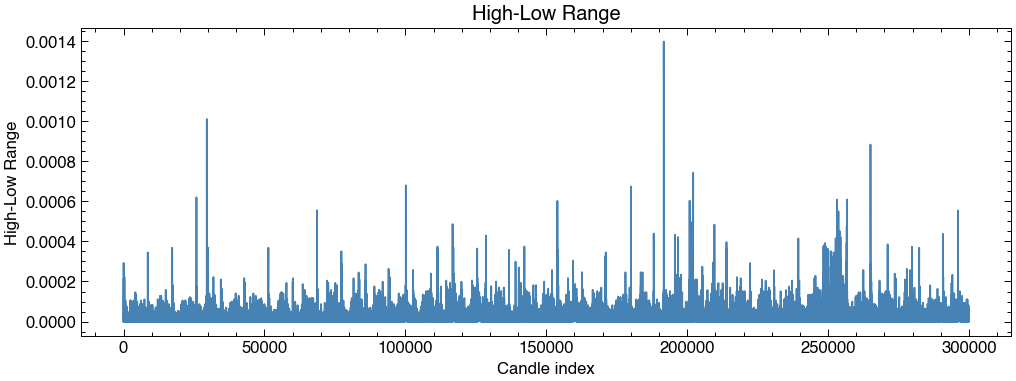

In [5]:
df = features.compute_high_low_range(df)

x = df.index
y = df['high_low_range']
plt.figure(figsize=(12,4))
plt.plot(x,y,c='steelblue')
plt.xlabel('Candle index')
plt.ylabel('High-Low Range')
plt.title('High-Low Range')
plt.show()

### Open-Close Difference (`open_close`)
- Captures the net price movement within a single candle, indicating whether the period was bullish or bearish.  
- Provides a simple measure of intra-candle volatility that complements high-low range and log returns.  
- Helps the model understand short-term price pressure and directional tendencies that can influence future volatility.

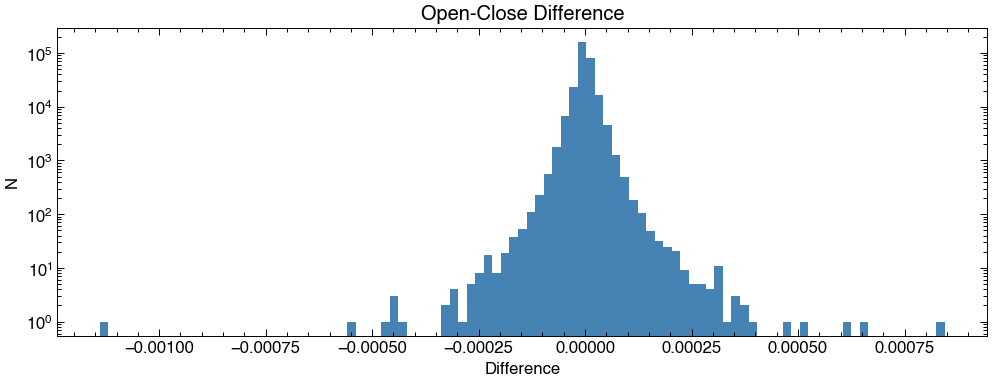

In [6]:
df = features.compute_open_close_diff(df)

y = df['open_close']
plt.figure(figsize=(12,4))
bins = np.linspace(min(y),max(y),100)
plt.hist(y,bins=bins,color='steelblue')
plt.yscale('log')
plt.title('Open-Close Difference')
plt.xlabel('Difference')
plt.ylabel('N')
plt.show()

### Log returns (`log_return`)
- Measure the proportional change in FX prices between consecutive candles, providing the raw, high-frequency price movement signal.  
- Serve as the fundamental building block for derived features like rolling statistics, lagged returns, and volatility measures.  
- Help the model detect immediate market activity and short-term fluctuations that influence future volatility.

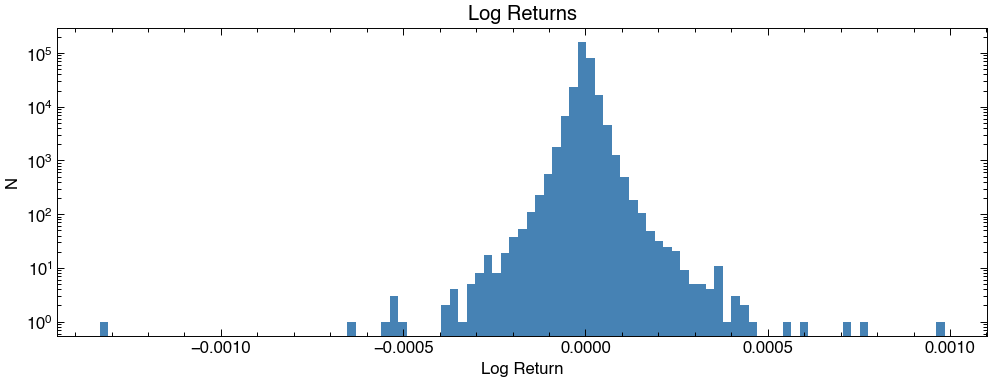

In [7]:
df = features.compute_log_returns(df)

y = df['log_return']
plt.figure(figsize=(12,4))
bins = np.linspace(min(y),max(y),100)
plt.hist(y,bins=bins,color='steelblue')
plt.yscale('log')
plt.title('Log Returns')
plt.xlabel('Log Return')
plt.ylabel('N')
plt.show()

### Logged lag returns (`log_return_lag_{lag}`)
- Capture recent momentum and directional patterns in FX price movements by including lagged log returns as features.  
- Each lag represents the log return from a previous candle, providing the model with temporal structure.  
- Helps the model identify periods of accelerating or decelerating volatility based on recent price dynamics.

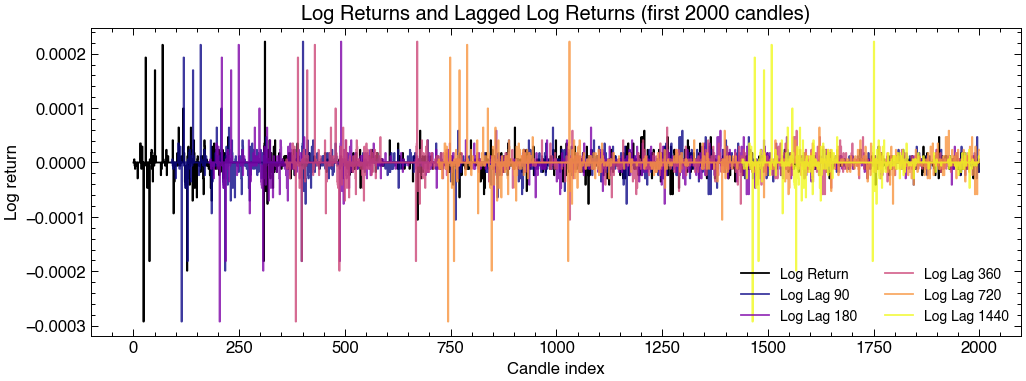

In [8]:
alpha = 1  # same for both
lag_multipliers = [0.25, 0.5, 1, 2, 4]
lag_seconds = [alpha * f * forecast_horizon for f in lag_multipliers]

df = features.logged_lag_returns(df, lag_seconds=lag_seconds)

time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
lag_steps = [int(ls / time_res) for ls in lag_seconds]

n = 2000
x = df.index[:n]
y0 = df['log_return'].iloc[:n]

plt.figure(figsize=(12,4))
plt.step(x,y0,label='Log Return',c='k',ls='-',where='mid')

colors = plt.cm.plasma(np.linspace(0,1,len(lag_steps)))
for indx, lag in enumerate(lag_steps):
    plt.step(x,df[f'log_return_lag_{lag}'].iloc[:n],label=f'Log Lag {lag}',alpha=0.8,color=colors[indx],where='mid')
plt.legend(loc='lower right',ncols=2)
plt.title(f'Log Returns and Lagged Log Returns (first {n} candles)')
plt.xlabel('Candle index')
plt.ylabel('Log return')
plt.show()

### Rolling statistics of Log Returns (`roll_mean`,`roll_std`)
- Capture short-term trends and volatility in recent returns.
- `roll_mean` can indicate temporary trends or drift in price.  
- `roll_std` shows short-term volatility, which is often predictive of future volatility spikes.
- Provide the model with smoothed summaries of past behavior, reducing noise from individual candles.

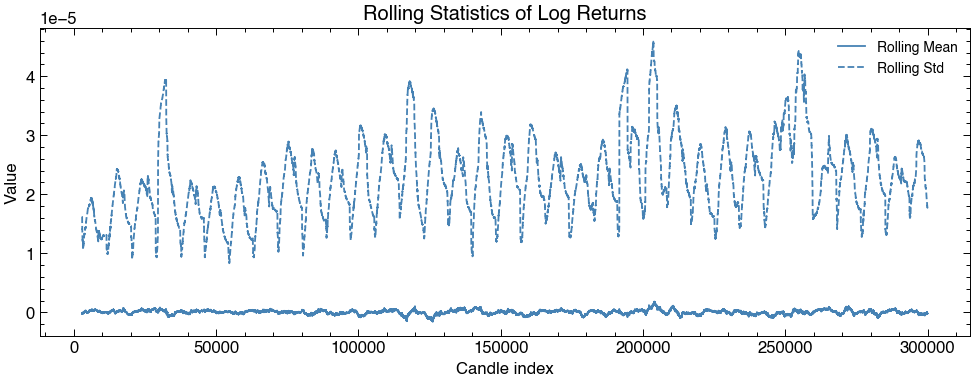

In [9]:
k = 8
window = k * forecast_horizon
df = features.compute_rolling_stats(df, window_seconds=window)

# Display first few rows to sanity-check
df[['roll_mean', 'roll_std']].head()

# Plot rolling mean and std for the first 500 rows
x = df.index#[:500]
y_mean = df['roll_mean']#.iloc[:500]
y_std = df['roll_std']#.iloc[:500]

plt.figure(figsize=(12,4))
plt.plot(x,y_mean,label='Rolling Mean', color='steelblue', ls='-')
plt.plot(x,y_std,label='Rolling Std', color='steelblue', ls='--')
plt.title('Rolling Statistics of Log Returns')
plt.xlabel('Candle index')
plt.ylabel('Value')
plt.legend()
plt.show()

### Past rolling volatility (`rolling_vol`)
- Computes the standard deviation of the last N candles from time t.
- Provides the most recent computed rolling volatility value as a feature, reflecting the immediate state of market fluctuations.
- Acts as a short-term baseline for predicting future volatility, leveraging the persistence and clustering properties of FX volatility.

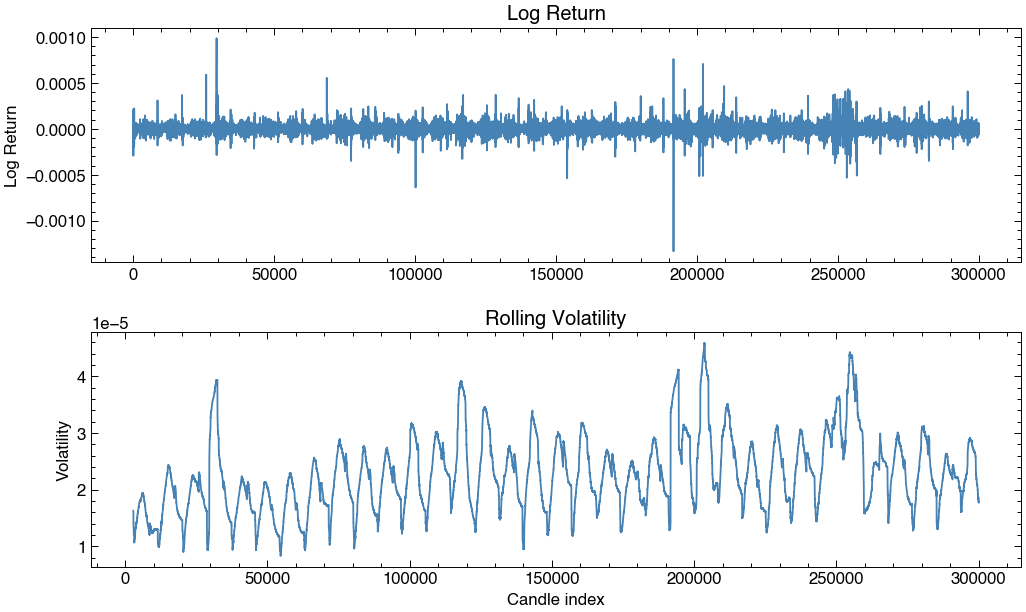

In [10]:
df = features.compute_rolling_volatility(df,window_seconds=window)

x = df.index
y1 = df['log_return']
y2 = df['rolling_vol']

plt.subplots(2,1,figsize=(12,7))
plt.subplot(2,1,1)
plt.plot(x,y1,c='steelblue')
plt.title('Log Return')
plt.ylabel('Log Return')
plt.subplot(2,1,2)
plt.plot(x,y2,c='steelblue')
plt.title('Rolling Volatility')
plt.ylabel('Volatility')
plt.xlabel('Candle index')
plt.subplots_adjust(hspace=0.3)
plt.show()

### Lagged rolling volatility (`rolling_vol_lag_{lag}`)
- Captures the temporal persistence of volatility by providing delayed snapshots of past volatility levels at horizon-scaled lags.
- Acts as an explicit memory of previous volatility regimes, allowing the model to learn how long elevated or suppressed volatility typically persists in FX markets.

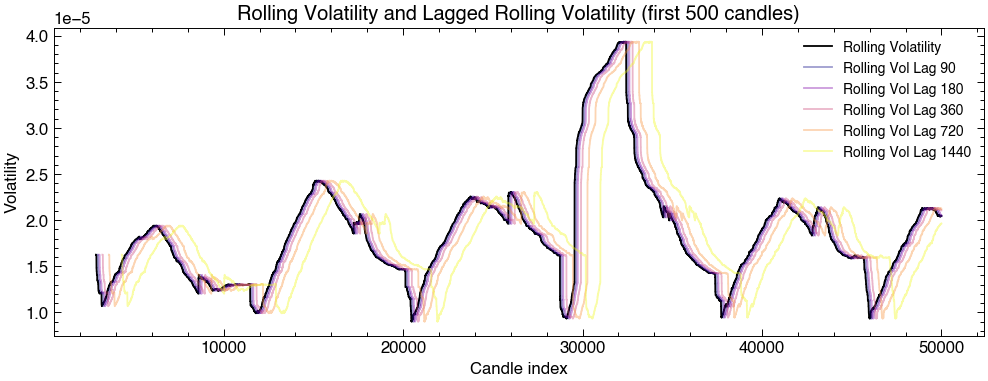

In [11]:
lag_multipliers = [0.25, 0.5, 1, 2, 4]
lag_seconds = [alpha * f * forecast_horizon for f in lag_multipliers]
df = features.compute_lagged_rolling_volatility(df,lag_seconds=lag_seconds,window_seconds=window)

time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
lag_steps = [int(ls / time_res) for ls in lag_seconds]

max_index = 50000
x = df.index[:max_index]
y0 = df['rolling_vol'].iloc[:max_index]

plt.figure(figsize=(12,4))
plt.step(x, y0, label='Rolling Volatility', c='k', where='mid')

colors = plt.cm.plasma(np.linspace(0,1,len(lag_steps)))
for indx, lag in enumerate(lag_steps):
    plt.step(x, df[f'rolling_vol_lag_{lag}'].iloc[:max_index], label=f'Rolling Vol Lag {lag}', alpha=0.4, color=colors[indx], where='mid')

plt.legend()
plt.title('Rolling Volatility and Lagged Rolling Volatility (first 500 candles)')
plt.xlabel('Candle index')
plt.ylabel('Volatility')
plt.show()


### Multi-window rolling volatility (`rolling_vol_{w}_cand`)
- Computes rolling volatility over multiple window lengths scaled to the forecast horizon, capturing volatility dynamics across short-, medium-, and longer-term timescales.
- Helps the model combine fast-reacting and slow-moving volatility signals, improving robustness to regime changes and reducing sensitivity to noise in any single window.

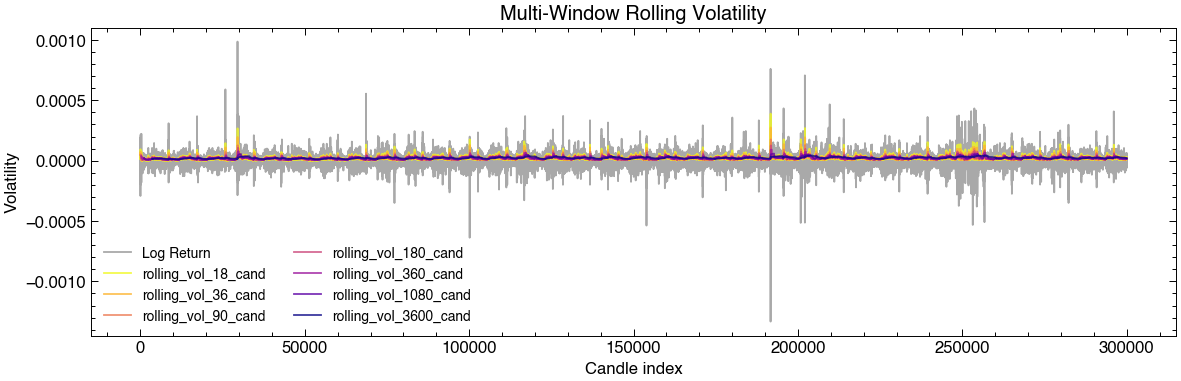

In [12]:
window_multipliers = [0.05, 0.1, 0.25, 0.5, 1, 3, 10]  # short, medium, long

df = features.compute_multi_window_rolling_vol(df, forecast_horizon, window_multipliers, base_col='log_return')

plt.figure(figsize=(14,4))

plt.step(df.index, df['log_return'], label='Log Return', color='darkgrey', alpha=1, where='mid')
colors = plt.cm.plasma_r(np.linspace(0,1,len(window_multipliers)))
for indx, k in enumerate(window_multipliers):
    window_candles = max(int(k * forecast_horizon / time_res), 1)
    plt.plot(df.index, df[f'rolling_vol_{window_candles}_cand'], label=f'rolling_vol_{window_candles}_cand', color=colors[indx], alpha=0.8)
    
plt.xlabel('Candle index')
plt.ylabel('Volatility')
plt.title(f'Multi-Window Rolling Volatility')
plt.legend(loc='lower left',ncols=2)
plt.show()


### Intra-day Seasonality (`tod_sin`,`tod_cos`)
- Captures systematic patterns in volatility or returns that recur at specific times of day (e.g., market open/close, London–New York overlap).  
- Provides the model with a "time of day context"i.
- Helps the model account for predictable temporal effects that are not explained by recent price dynamics or rolling volatility, improving short- to medium-term forecast accuracy.

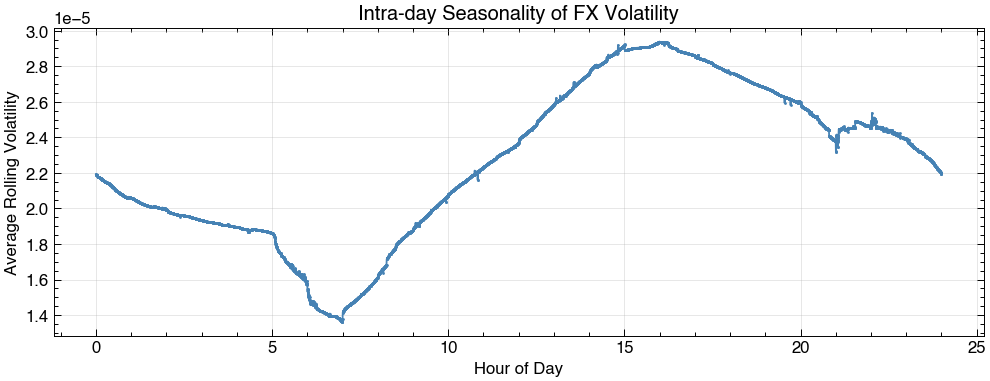

In [13]:
df = features.compute_intraday_seasonality(df)

seconds_in_day = 24*60*60
time_of_day_sec = df['timestamp'].dt.hour*3600 + df['timestamp'].dt.minute*60 + df['timestamp'].dt.second
df['hour_of_day'] = time_of_day_sec / 3600  # 0-24 hours

# Optionally, aggregate rolling_vol by hour of day to see average pattern
hourly_vol = df.groupby('hour_of_day')['rolling_vol'].mean()

plt.figure(figsize=(12,4))
plt.plot(hourly_vol.index, hourly_vol.values, marker='o',markersize=1,c='steelblue')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rolling Volatility')
plt.title('Intra-day Seasonality of FX Volatility')
plt.grid(alpha=0.3)
plt.show()

### Volatility slope (`vol_slope`)
- Measures the recent trend in volatility by capturing whether volatility is increasing or decreasing over a short, horizon-aligned window.
- Helps the model anticipate volatility regime transitions by providing directional information about upcoming changes in volatility.

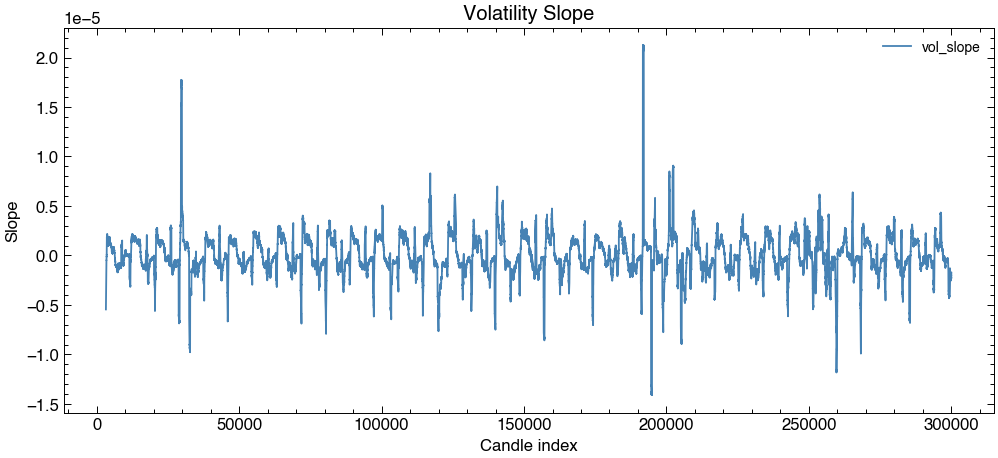

In [14]:
df = features.compute_volatility_slope(df,forecast_horizon)

plt.figure(figsize=(12,5))
plt.plot(df.index,df['vol_slope'],label='vol_slope',c='steelblue')
plt.title('Volatility Slope')
plt.ylabel('Slope')
plt.xlabel('Candle index')
plt.legend()
plt.show()

### Volatility z-score (`vol_zscore`)
- Measures how extreme the current volatility level is relative to its recent regime (defined over a horizon-aligned window), providing scale-aware context.
- Helps the model distinguish between normal fluctuations and tail regimes, improving its ability to predict the *magnitude* of future volatility rather than just its direction.

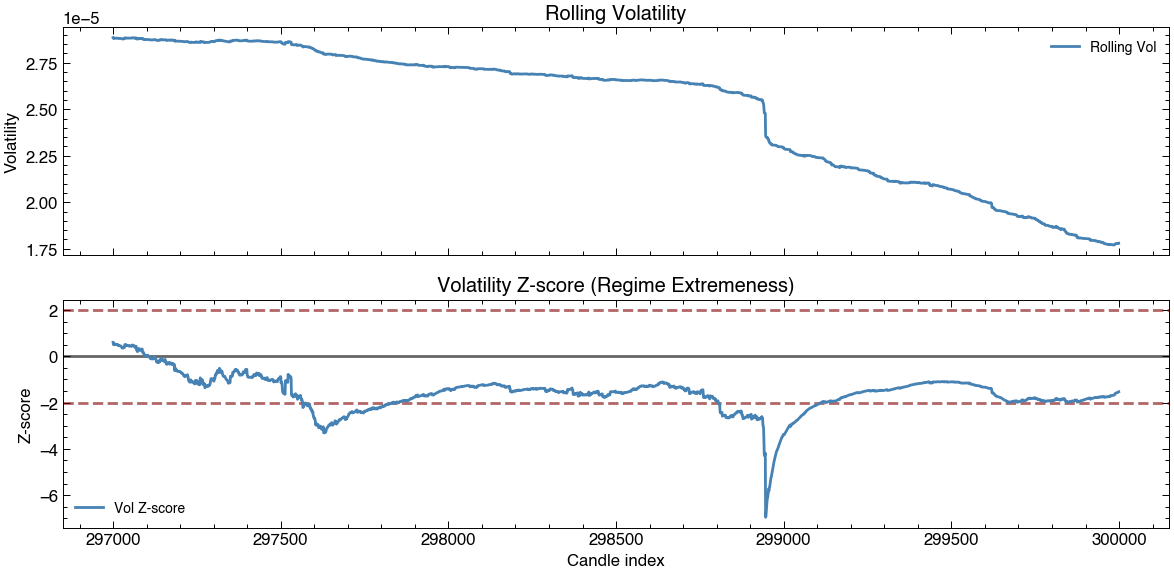

In [15]:
z_window_multiplier = 2
df = features.compute_volatility_zscore(df,forecast_horizon,z_window_multiplier)

N = 3000  # last N candles
start = max(len(df) - N, 0)

x = np.arange(start, len(df))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Rolling volatility
axes[0].plot(x, df['rolling_vol'].iloc[start:], c='steelblue', lw=2, label='Rolling Vol')
axes[0].set_ylabel('Volatility')
axes[0].set_title('Rolling Volatility')

# Volatility z-score
axes[1].plot(x, df['vol_zscore'].iloc[start:], color='steelblue', lw=2, label='Vol Z-score',zorder=4)
axes[1].axhline(0, color='k', lw=2, alpha=0.6)
axes[1].axhline(2, color='maroon', lw=2, ls='--', alpha=0.6)
axes[1].axhline(-2, color='maroon', lw=2, ls='--', alpha=0.6)
axes[1].set_ylabel('Z-score')
axes[1].set_title('Volatility Z-score (Regime Extremeness)')
axes[1].set_xlabel('Candle index')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

## Target
- Target of the candle data that we are aiming to predict using ML.

### Future rolling volatility (`rolling_future_vol`)

- Future rolling volatility shows strong temporal persistence.
- Peaks in future volatility align with peaks in past rolling volatility.
- This reflects volatility clustering: periods of high volatility tend to be followed by high volatility.
- The target is computed strictly from data in the interval t → t+H, so this alignment is causal, not information leakage.
- This validates that past volatility contains predictive information about future volatility.
- The model’s task is therefore to learn the mapping from past volatility regimes to future volatility magnitude.
- Any predictive power beyond this persistence will be captured by the non-linear structure of the gradient boosting model.

# 

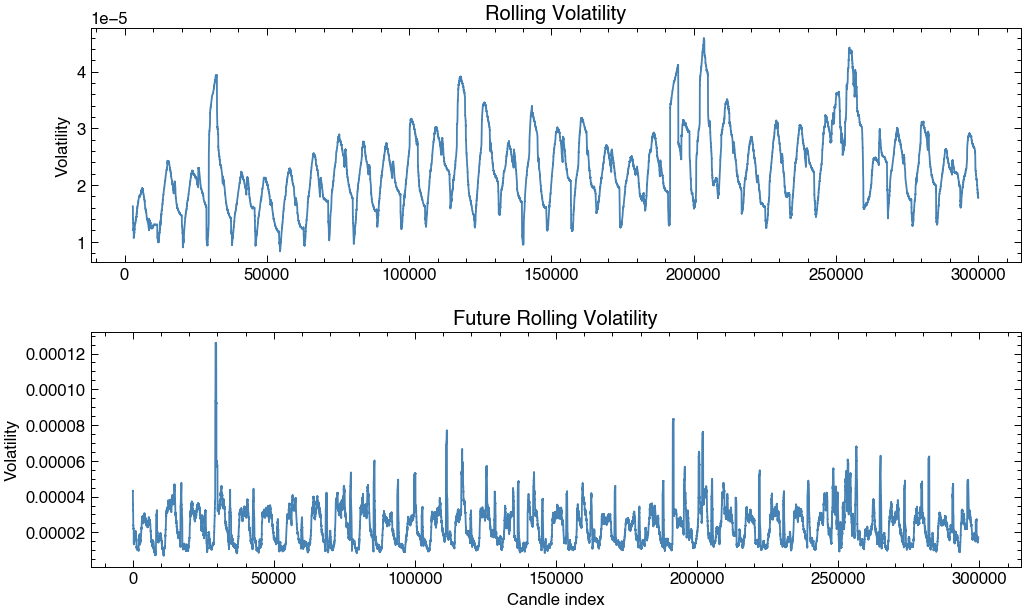

In [17]:
df = df.copy()
df = features.compute_future_rolling_volatility(df,horizon=forecast_horizon)

eps = 1e-8 #volatility can be too close to zero
df['rolling_log_future_vol'] = np.log(df['rolling_future_vol'] + eps)

x = df.index
y1 = df['rolling_vol']
y2 = df['rolling_future_vol']

plt.subplots(2,1,figsize=(12,7))
plt.subplot(2,1,1)
plt.title('Rolling Volatility')
plt.plot(x,y1,c='steelblue')
plt.ylabel('Volatility')
plt.subplot(2,1,2)
plt.title('Future Rolling Volatility')
plt.plot(x,y2,c='steelblue')
plt.ylabel('Volatility')
plt.xlabel('Candle index')
plt.subplots_adjust(hspace=0.3)
plt.show()

## Machine Learning

### 1. Split Data

We split the dataset chronologically to preserve temporal dependencies:
- Training set: used to fit the Gradient Boosting model
- Test set: used to evaluate out-of-sample predictive performance
- Validation set: used to monitor model performance on unseen data

Features: past rolling volatility (`rolling_vol`)  
Target: forward-looking volatility (`rolling_future_vol`)


In [18]:
time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
lag_steps = [int(ls / time_res) for ls in lag_seconds]
window_candles_list = [max(int(k * forecast_horizon / time_res), 1) for k in window_multipliers]

# feature_cols = ['rolling_vol', 'roll_mean', 'roll_std', 'high_low_range', 'log_return', 'open_close'] + \
#     [f'log_return_lag{i}' for i in range(1, n_lags+1)] + \
#         [f'rolling_vol_lag_{lag}' for lag in lag_steps] + \
#         [f'rolling_vol_{w}_cand' for w in window_candles_list]

feature_cols = ['rolling_vol'] + [f'rolling_vol_lag_{lag}' for lag in lag_steps] + \
    [f'rolling_vol_{w}_cand' for w in window_candles_list] + ['tod_sin', 'tod_cos', 'vol_of_vol'] + ['vol_slope'] + ['vol_zscore']

X_train, X_test, y_train, y_test = model.split_data(df, feature_cols, target_col='rolling_log_future_vol', train_frac=0.8)

val_frac = 0.1
val_index = int(len(X_train) * (1 - val_frac))
X_tr, X_val = X_train[:val_index], X_train[val_index:]
y_tr, y_val = y_train[:val_index], y_train[val_index:]

print(f"Training samples: {len(X_tr)}, Test samples: {len(X_test)}, Validation samples: {len(X_val)}")

Training samples: 211594, Test samples: 58777, Validation samples: 23511


### 2. Train Model

We train a Gradient Boosting Regressor to predict forward-looking volatility:
- Uses features from past rolling volatility
- Predicts aggregate volatility over the specified horizon

In [19]:
gb_params = {
    'n_estimators': 100,      
    'learning_rate': 0.1,     
    'max_depth': 3,            
    'random_state': 42,        
    # Optional LightGBM-specific speed-ups:
    'num_leaves': 31,          # default leaf-wise growth
    'feature_fraction': 0.9,   # subsample features per tree
    'bagging_fraction': 0.8,   # subsample rows per iteration
    'bagging_freq': 5,         # perform bagging every 5 rounds
    'verbosity': -1
}

# Now you can train the model on X, y
ml_model = model.train_model(X_tr,y_tr,X_val,y_val,**gb_params)

### 3. Evaluate Model

We evaluate the model on the test set using:
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

Compare predicted and actual forward volatility on the test set:
- Peaks in prediction should align with realized volatility peaks
- Confirms model is capturing temporal patterns in volatility

/Users/dominictaylor/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE: 0.310091
MAE: 0.229877


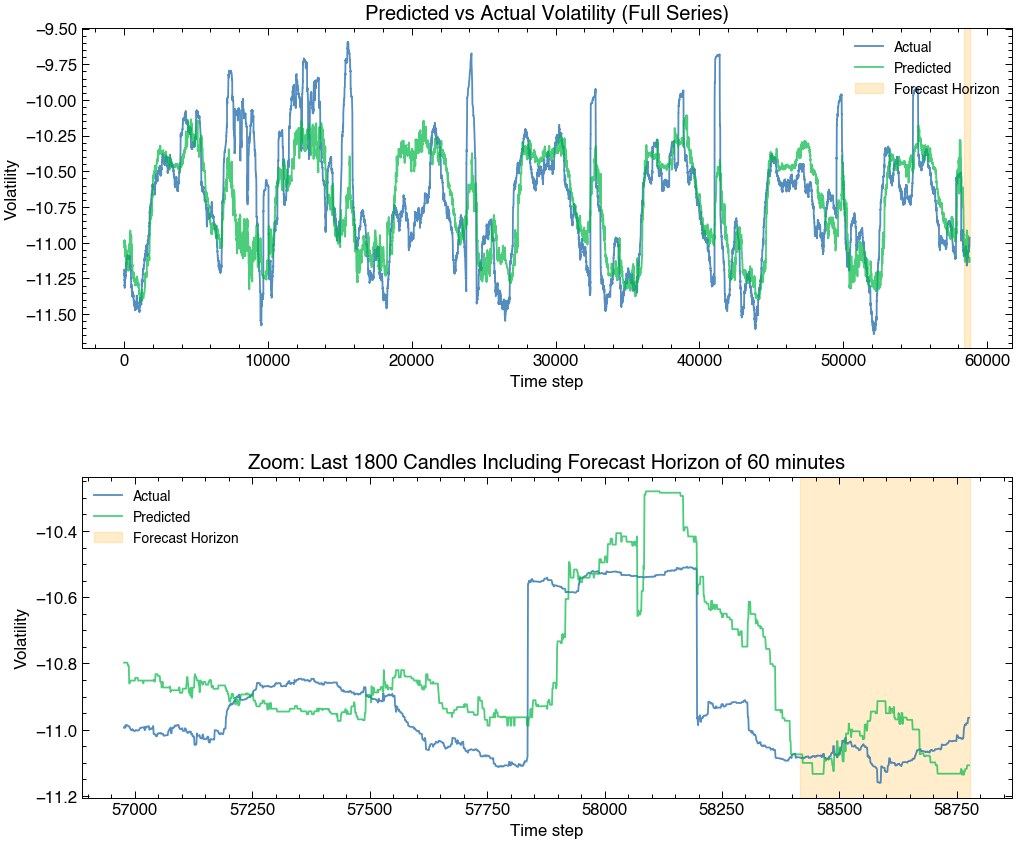

In [20]:
y_pred_log, y_pred_vol, rmse_log, mae_log = model.evaluate_model(ml_model, X_test, y_test)

# #transform back from log to linear volatility
# y_pred_transform = 

print(f"RMSE: {rmse_log:.6f}")
print(f"MAE: {mae_log:.6f}")

time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
H = int(forecast_horizon / time_res)

zoom_len = 5 * H
start_zoom = max(len(y_test) - zoom_len, 0)
x_full = np.arange(len(y_test))
x_zoom = np.arange(start_zoom, len(y_test))

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Full series
axes[0].plot(x_full, y_test, label='Actual', alpha=0.7)
axes[0].plot(x_full, y_pred_log, label='Predicted', alpha=0.7)
axes[0].axvspan(len(y_test)-H, len(y_test), color='orange', alpha=0.2, label='Forecast Horizon')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Volatility')
axes[0].set_title('Predicted vs Actual Volatility (Full Series)')
axes[0].legend()

# Zoomed-in view
axes[1].plot(x_zoom, y_test[start_zoom:], label='Actual', alpha=0.7)
axes[1].plot(x_zoom, y_pred_log[start_zoom:], label='Predicted', alpha=0.7)
axes[1].axvspan(len(y_test)-H, len(y_test), color='orange', alpha=0.2, label='Forecast Horizon')  # optional: adjust to match zoom
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Volatility')
axes[1].set_title(f'Zoom: Last {int(zoom_len)} Candles Including Forecast Horizon of {hmins} minutes')
axes[1].legend()

plt.subplots_adjust(hspace=0.4)
plt.show()

### Feature Importance

- Shows which features the model considers most useful for predicting future volatility.
- Can help identify which aspects of past price behaviour (log returns, rolling stats, high-low range, lagged returns) drive the predictions.

                  feature  importance
13                tod_sin         106
15             vol_of_vol          84
14                tod_cos          76
5    rolling_vol_lag_1440          68
11  rolling_vol_1080_cand          65
4     rolling_vol_lag_720          43
12  rolling_vol_3600_cand          36
10   rolling_vol_360_cand          33
0             rolling_vol          32
16              vol_slope          26
9    rolling_vol_180_cand          23
3     rolling_vol_lag_360          20
8     rolling_vol_90_cand          19
17             vol_zscore          18
7     rolling_vol_36_cand          17
2     rolling_vol_lag_180          13
1      rolling_vol_lag_90          12
6     rolling_vol_18_cand           5


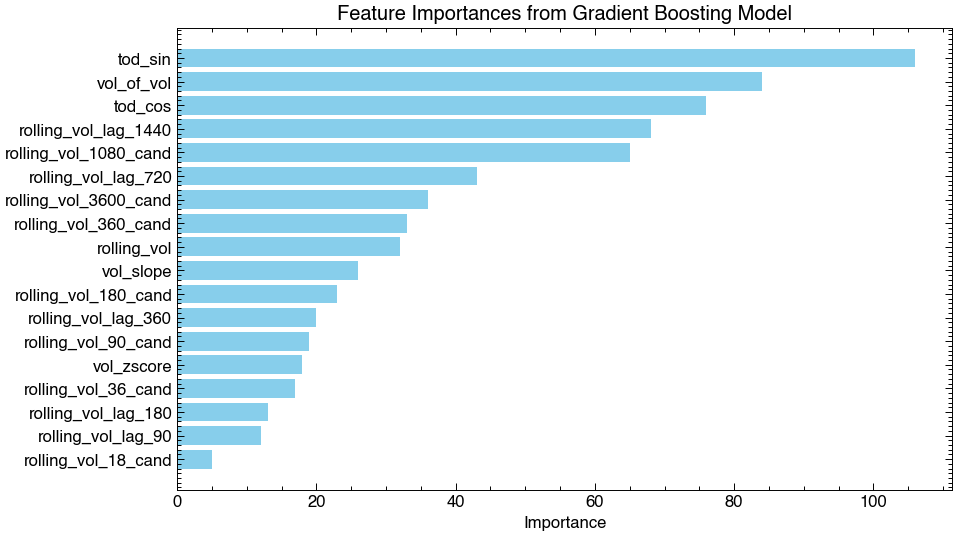

In [21]:
feat_importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': ml_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display the table
print(feat_importances)

# Plot feature importances
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'], feat_importances['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances from Gradient Boosting Model')
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()